In [1]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

In [2]:
import pytorch_lightning
from monai.utils import set_determinism
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    ScaleIntensityRanged,
    Spacingd,
    RandFlipd,
    RandAdjustContrastd,
    RandRotate90d,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandSpatialCropd,
    EnsureType,
)
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, list_data_collate, decollate_batch, DataLoader
from monai.config import print_config
from monai.apps import download_and_extract
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob
import numpy as np

print_config()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


MONAI version: 1.5.1
Numpy version: 2.3.5
Pytorch version: 2.9.1+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 9c6d819f97e37f36c72f3bdfad676b455bd2fa0d
MONAI __file__: /home/<username>/sebastian_ma/VoronoiLoss/.venv/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.5
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 12.0.0
Tensorboard version: 2.20.0
gdown version: 5.2.0
TorchVision version: 0.24.1+cu126
tqdm version: 4.67.1
lmdb version: 1.7.5
psutil version: 7.1.3
pandas version: 2.3.3
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: 3.7.0
pynrrd version: 1.1.3
clearml version: 2.0.2

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [3]:
ROOT_DIR = '../../data/platelet-em'
TASK = 'Task3_alphagranule'
task_data_dir = f'{ROOT_DIR}/{TASK}'
assert os.path.exists(f'{task_data_dir}')
assert os.path.exists(f'{task_data_dir}/imagesTr')
assert os.path.exists(f'{task_data_dir}/labelsTr')
assert len(os.listdir(f'{task_data_dir}/imagesTr')) > 0
assert len(os.listdir(f'{task_data_dir}/labelsTr')) > 0
assert len(os.listdir(f'{task_data_dir}/labelsTr')) == len(os.listdir(f'{task_data_dir}/imagesTr'))
assert os.listdir(f'{task_data_dir}/labelsTr') == os.listdir(f'{task_data_dir}/imagesTr')

In [4]:
class Net(pytorch_lightning.LightningModule):
    def __init__(self):
        super().__init__()
        self._model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=2,
            channels=(16, 32, 64, 128),
            strides=(2, 2, 2),
            num_res_units=2,
            norm=Norm.BATCH,
        )
        self.loss_function = DiceLoss(to_onehot_y=True, softmax=True)
        self.post_pred = Compose(
            [EnsureType("tensor", device="cpu"), AsDiscrete(argmax=True, to_onehot=2)])
        self.post_label = Compose(
            [EnsureType("tensor", device="cpu"), AsDiscrete(to_onehot=2)])
        self.dice_metric = DiceMetric(
            include_background=False, reduction="mean", get_not_nans=False)
        self.best_val_dice = 0
        self.best_val_epoch = 0
        self.validation_step_outputs = []

    def forward(self, x):
        return self._model(x)

    def prepare_data(self):
        # set up the correct data path
        train_images = sorted(glob.glob(os.path.join(
            task_data_dir, "imagesTr", "*.nii.gz")))
        train_labels = sorted(glob.glob(os.path.join(
            task_data_dir, "labelsTr", "*.nii.gz")))
        data_dicts = [
            {"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)
        ]
        train_files, val_files = data_dicts[:-9], data_dicts[-9:]

        # set deterministic training for reproducibility
        set_determinism(seed=0)

        # define the data transforms
        train_transforms = Compose(
            [
                LoadImaged(keys=["image", "label"]),
                EnsureChannelFirstd(keys=["image", "label"]),
                Orientationd(keys=["image", "label"], axcodes="RAS"),
                Spacingd(
                    keys=["image", "label"],
                    pixdim=(10, 10, 40),
                    mode=("bilinear", "nearest"),
                ), NormalizeIntensityd(
                    keys=["image"],
                    nonzero=False,  # Set to True if you want to ignore background zeros
                    channel_wise=True
                ), RandSpatialCropd(
                    keys=["image", "label"],
                    roi_size=(256, 256, 48),
                    random_center=True,
                    random_size=False
                ),
                # 3. Mirrors / Flips (Prob = 0.5)
                RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
                RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
                RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
                # 4. Rotations (90-degree increments are faster than interpolation)
                RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
                # 5. Gaussian Noise (Standard for EM data)
                RandGaussianNoised(
                    keys=["image"], prob=0.15, mean=0.0, std=0.1),
                # 6. Gaussian Blur
                RandGaussianSmoothd(
                    keys=["image"],
                    sigma_x=(0.5, 1.15),
                    sigma_y=(0.5, 1.15),
                    sigma_z=(0.5, 1.15),
                    prob=0.15,
                ),
                # 7. Contrast Adjustment
                RandAdjustContrastd(
                    keys=["image"], prob=0.15, gamma=(0.7, 1.5)),
            ]
        )
        val_transforms = Compose(
            [
                LoadImaged(keys=["image", "label"]),
                EnsureChannelFirstd(keys=["image", "label"]),
                Orientationd(keys=["image", "label"], axcodes="RAS"),
                Spacingd(
                    keys=["image", "label"],
                    pixdim=(10, 10, 40),
                    mode=("bilinear", "nearest"),
                ), NormalizeIntensityd(
                    keys=["image"],
                    nonzero=False,  # Set to True if you want to ignore background zeros
                    channel_wise=True
                ),
            ]
        )

        # we use cached datasets - these are 10x faster than regular datasets
        self.train_ds = CacheDataset(
            data=train_files,
            transform=train_transforms,
            cache_rate=1.0,
            num_workers=4,
        )
        self.val_ds = CacheDataset(
            data=val_files,
            transform=val_transforms,
            cache_rate=1.0,
            num_workers=4,
        )

    def train_dataloader(self):
        train_loader = DataLoader(
            self.train_ds,
            batch_size=2,
            shuffle=True,
            num_workers=4,
            collate_fn=list_data_collate,
        )
        return train_loader

    def val_dataloader(self):
        val_loader = DataLoader(self.val_ds, batch_size=1, num_workers=4)
        return val_loader

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self._model.parameters(), 1e-4)
        return optimizer

    def training_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        output = self.forward(images)
        loss = self.loss_function(output, labels)
        tensorboard_logs = {"train_loss": loss.item()}
        return {"loss": loss, "log": tensorboard_logs}

    def validation_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        roi_size = (256, 256, 48)
        sw_batch_size = 4
        outputs = sliding_window_inference(
            images, roi_size, sw_batch_size, self.forward)
        loss = self.loss_function(outputs, labels)
        outputs = [self.post_pred(i) for i in decollate_batch(outputs)]
        labels = [self.post_label(i) for i in decollate_batch(labels)]
        self.dice_metric(y_pred=outputs, y=labels)
        d = {"val_loss": loss, "val_number": len(outputs)}
        self.validation_step_outputs.append(d)
        return d

    def on_validation_epoch_end(self):
        val_loss, num_items = 0, 0
        for output in self.validation_step_outputs:
            val_loss += output["val_loss"].sum().item()
            num_items += output["val_number"]
        mean_val_dice = self.dice_metric.aggregate().item()
        self.dice_metric.reset()
        mean_val_loss = torch.tensor(val_loss / num_items)
        tensorboard_logs = {
            "val_dice": mean_val_dice,
            "val_loss": mean_val_loss,
        }
        if mean_val_dice > self.best_val_dice:
            self.best_val_dice = mean_val_dice
            self.best_val_epoch = self.current_epoch
        print(
            f"current epoch: {self.current_epoch} "
            f"current mean dice: {mean_val_dice:.4f}"
            f" best dice {self.best_val_dice:.4f} at epoch: {self.best_val_epoch}"
        )
        self.validation_step_outputs.clear()  # free memory
        return {"log": tensorboard_logs}

In [ ]:
# 1. Initialize your net and run prepare_data to setup self.train_ds
net = Net()
net.prepare_data()

# 2. Grab a single sample from the CacheDataset
check_ds = net.train_ds[0]
image, label = check_ds["image"], check_ds["label"]

print(f"Image shape: {image.shape}")  # Should be (1, 256, 256, 48)
print(f"Image range: {image.min()} to {image.max()}")  # Should be [0, 1]
print(f"Label unique values: {np.unique(label)}")  # Should be [0, 1]

# 3. Visualize a slice in the middle of the 3D stack
slice_idx = 24
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Augmented Image")
plt.imshow(image[0, :, :, slice_idx], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Augmented Label")
plt.imshow(label[0, :, :, slice_idx])
plt.show()

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
Loading dataset:  14%|█▍        | 16/112 [00:04<00:19,  4.84it/s]

In [ ]:
# set up loggers and checkpoints
log_dir = os.path.join(task_data_dir, "logs")
tb_logger = pytorch_lightning.loggers.TensorBoardLogger(save_dir=log_dir)

# initialise Lightning's trainer.
trainer = pytorch_lightning.Trainer(
    devices=[0],
    max_epochs=5,
    logger=tb_logger,
    enable_checkpointing=True,
    num_sanity_val_steps=1,
    log_every_n_steps=16,
)

# train
trainer.fit(net)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Loading dataset: 100%|██████████| 9/9 [00:01<00:00,  8.37it/s]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _model        │ UNet     │  1.2 M │ train │     0 │
│ 1 │ loss_function │ DiceLoss │      0 │ train │     0 │
└───┴───────────────┴──────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 112                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

current epoch: 0 current mean dice: 0.0607 best dice 0.0607 at epoch: 0

In [21]:
print(f"train completed, best_metric: {net.best_val_dice:.4f} " f"at epoch {net.best_val_epoch}")

train completed, best_metric: 0.9136 at epoch 96


In [22]:
# %load_ext tensorboard
# %tensorboard --logdir=$log_dir

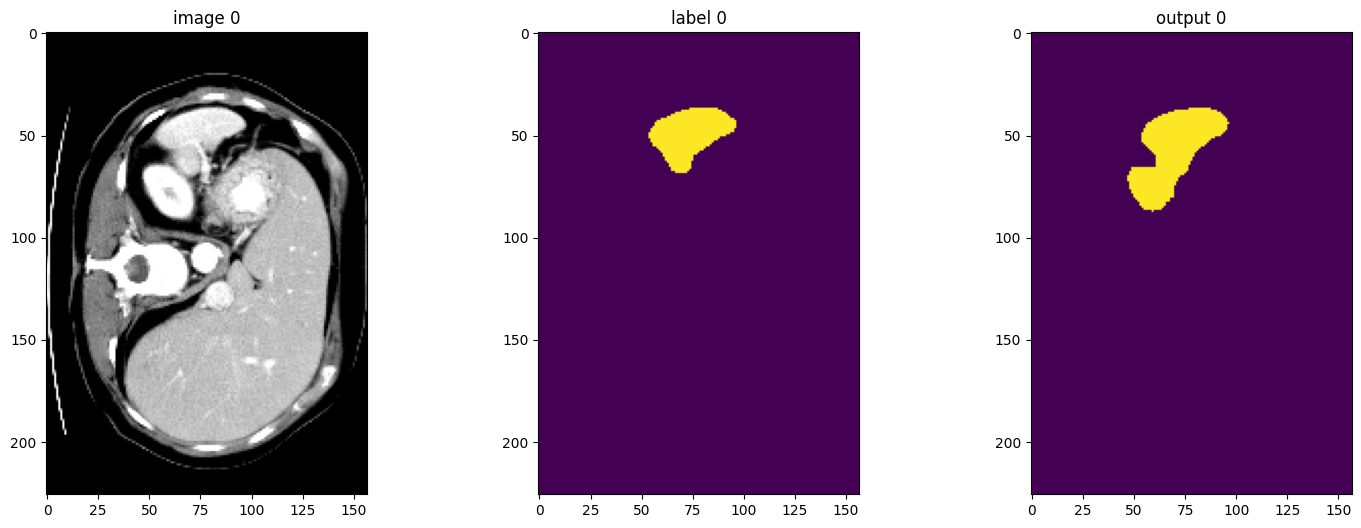

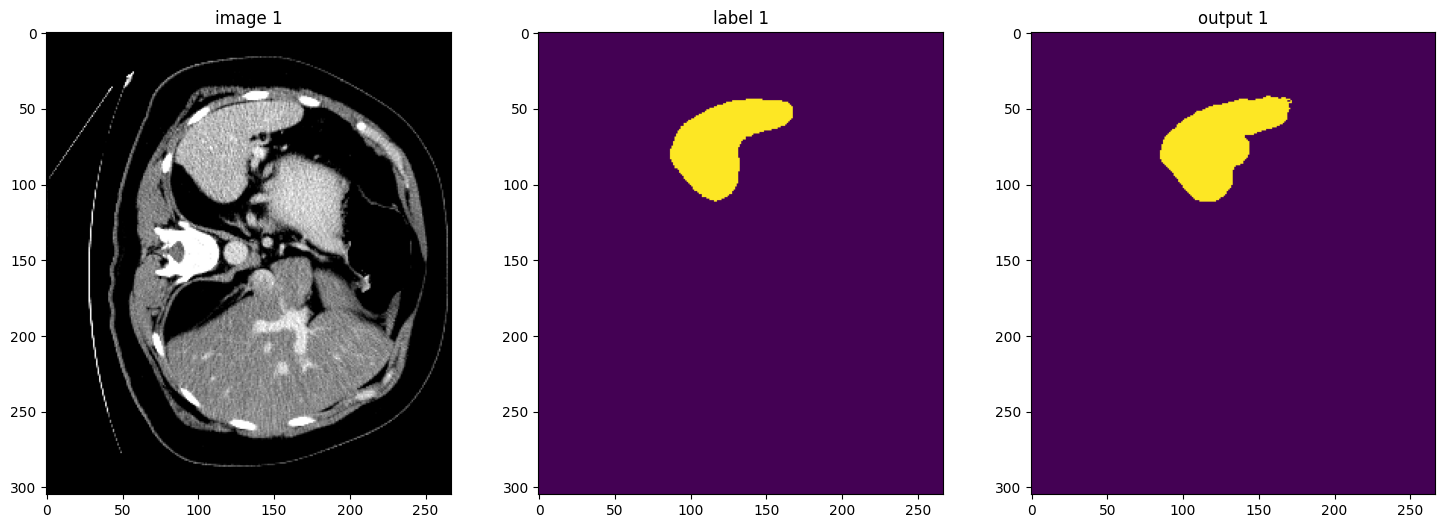

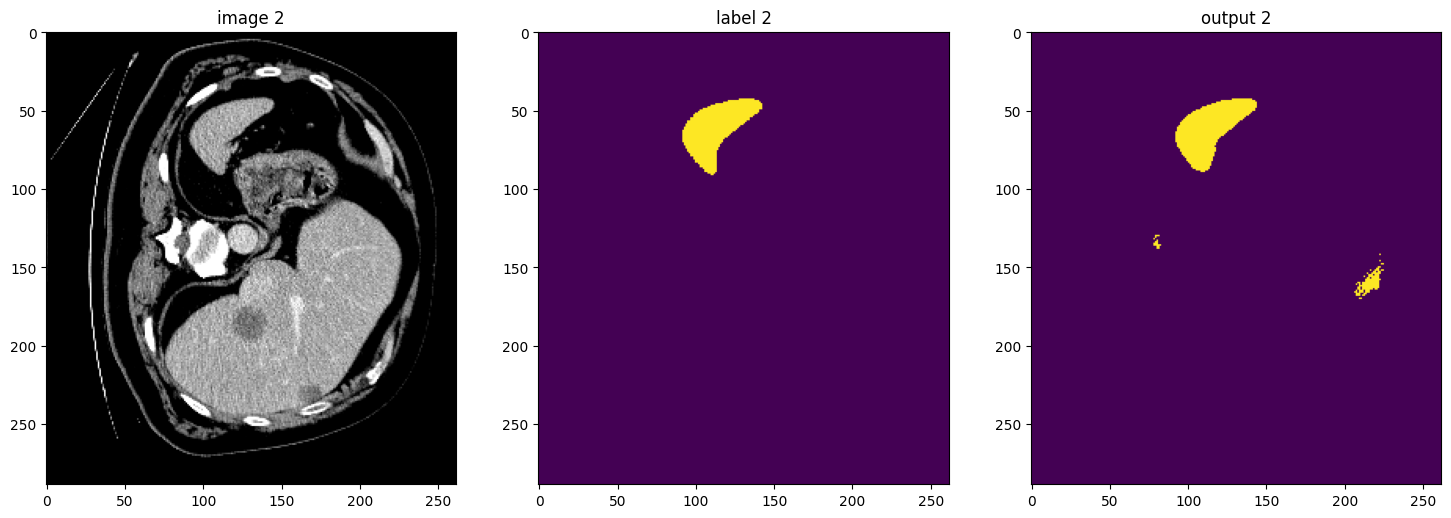

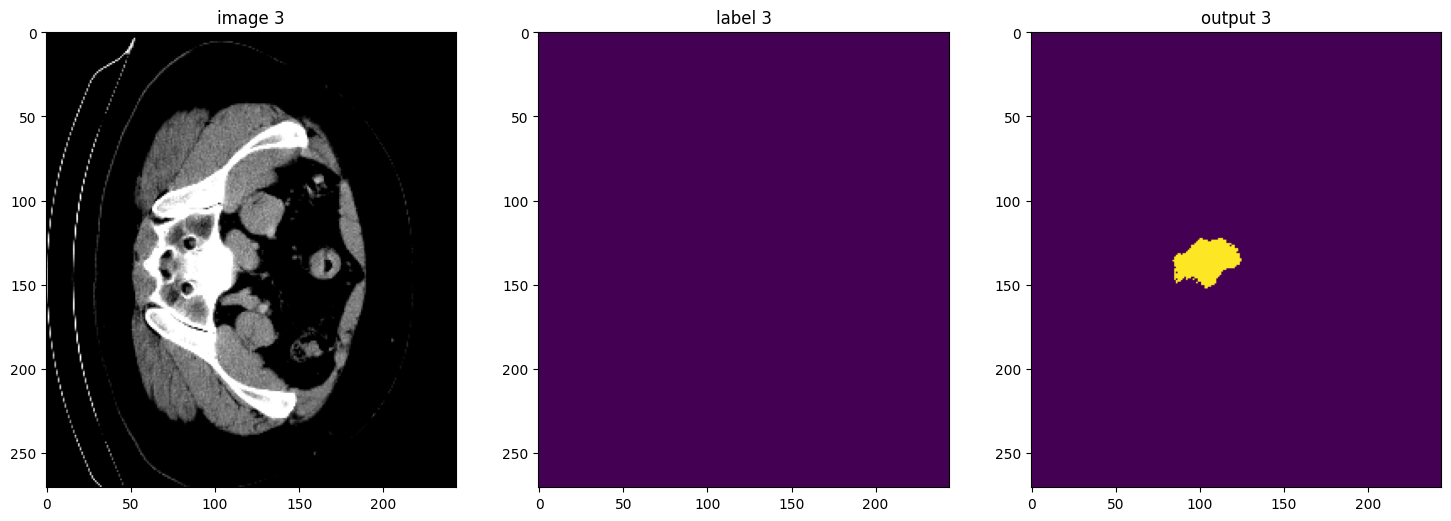

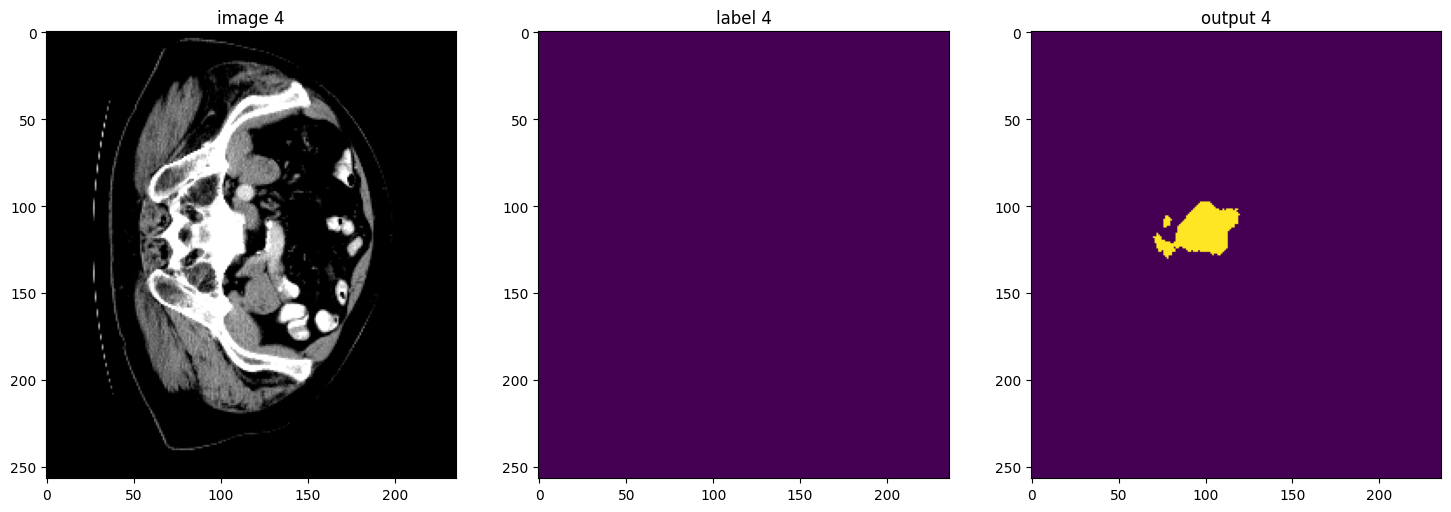

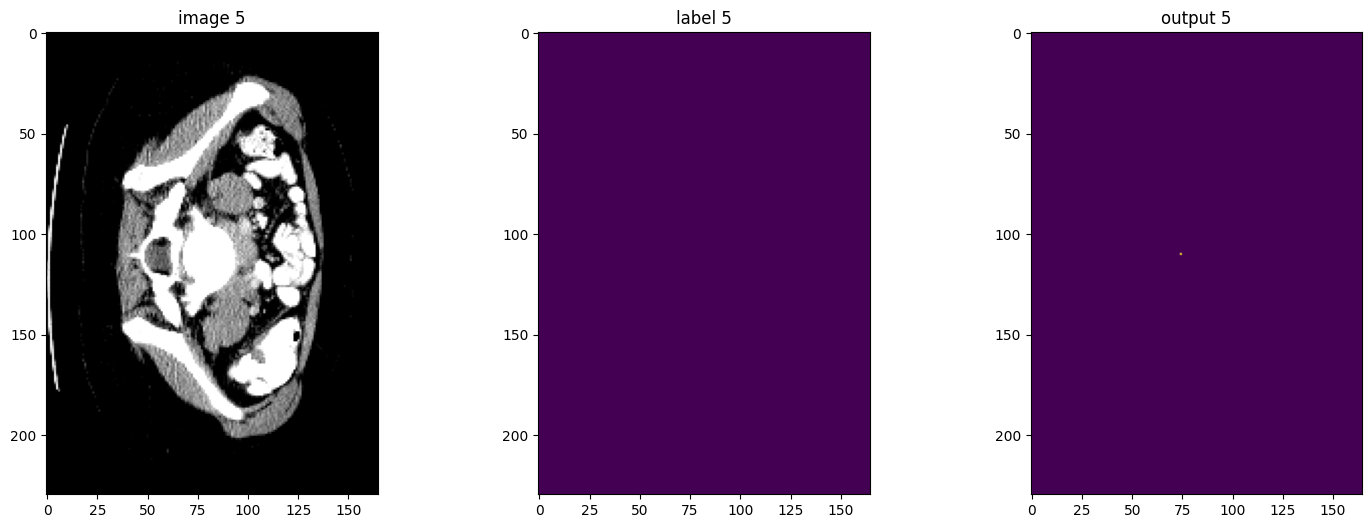

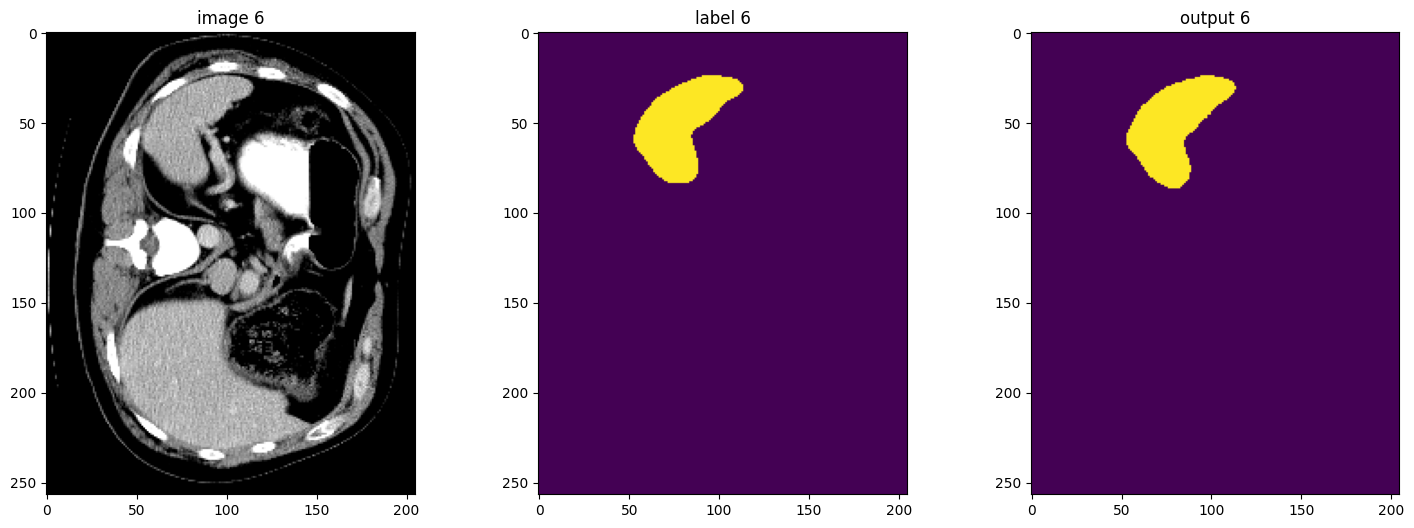

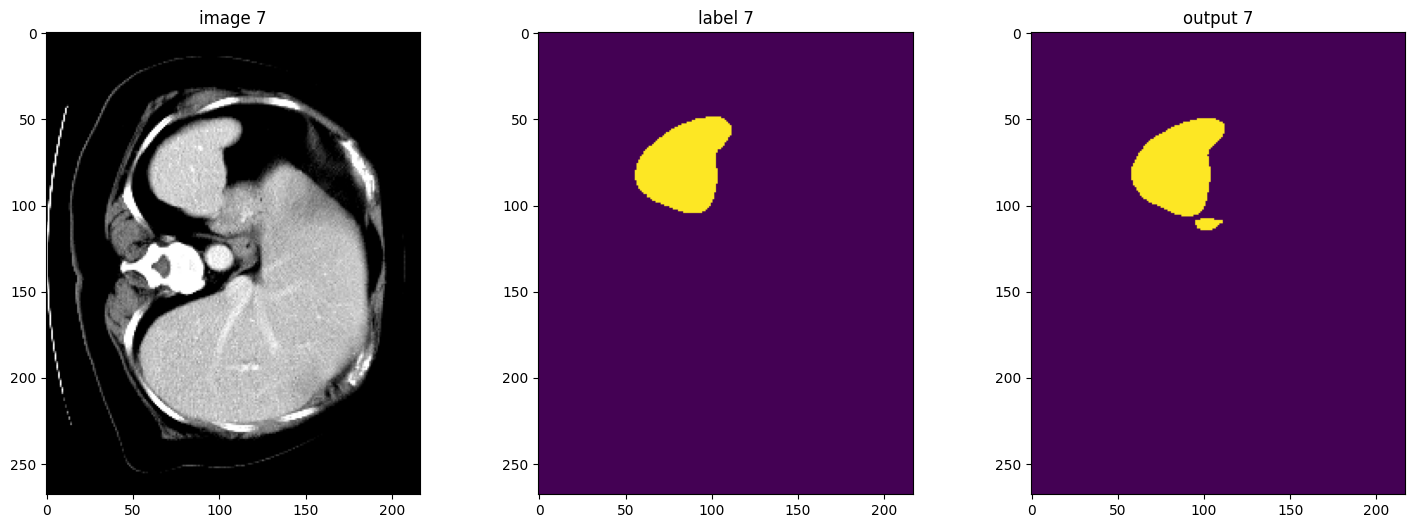

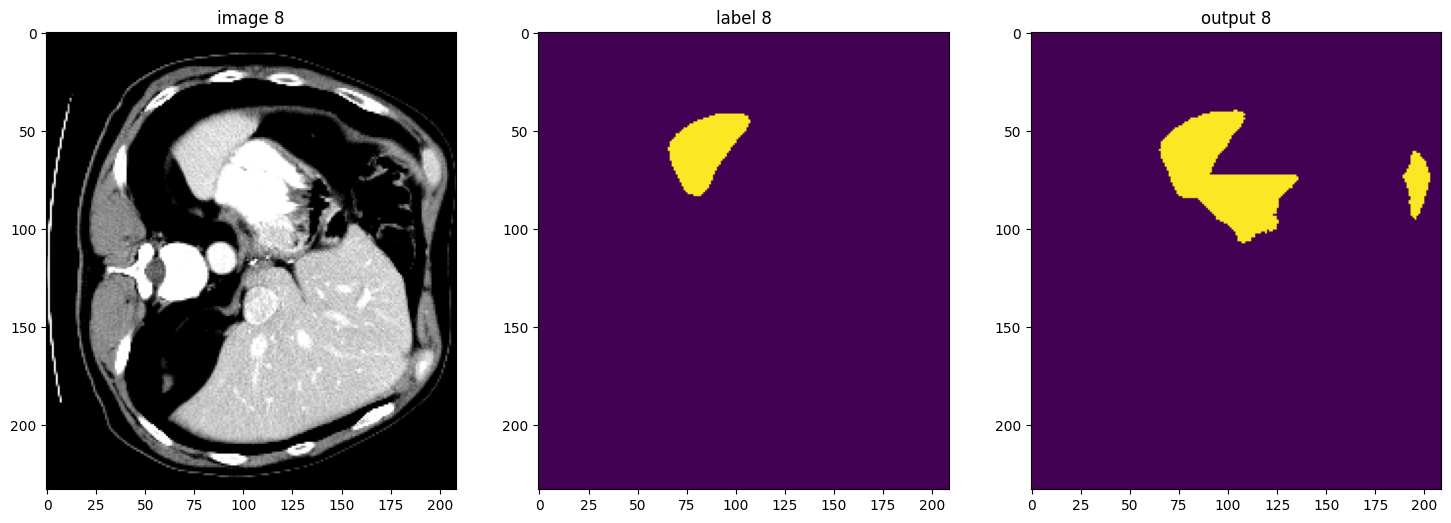

In [23]:
net.eval()
device = torch.device("cuda:0")
net.to(device)
with torch.no_grad():
    for i, val_data in enumerate(net.val_dataloader()):
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, net)
        # plot the slice [:, :, 80]
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, :, :, 80], cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["label"][0, 0, :, :, 80])
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        plt.imshow(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, 80])
        plt.show()